In [1]:
import sys
from pathlib import Path
import time
import random

sys.path.append("../src")

import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

from dataset import ProcessedDeepGlobeDataset
from data_transforms import get_train_transform, get_val_transform
from model import get_model
from train import train_one_epoch, validate_one_epoch

In [2]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
def seed_worker(worker_id):
    worker_seed = 42 + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)
g = torch.Generator()
g.manual_seed(42)    
set_seed(42)
print("Seed set to 42")

Seed set to 42


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Using device: cuda
GPU: NVIDIA GeForce RTX 5070 Ti


In [4]:
processed_img_dir = Path("../data/processed/train_images")
processed_mask_dir = Path("../data/processed/train_masks")

processed_images = sorted(processed_img_dir.glob("*.npy"))
processed_masks = sorted(processed_mask_dir.glob("*.npy"))

print("Processed images:", len(processed_images))
print("Processed masks:", len(processed_masks))
print("First image file:", processed_images[0].name)
print("First mask file:", processed_masks[0].name)

Processed images: 803
Processed masks: 803
First image file: 100694_sat.npy
First mask file: 100694_mask.npy


In [5]:
dataset_size = len(processed_images)
train_size = int(0.8 * dataset_size)
val_size = dataset_size - train_size

train_img_paths = processed_images[:train_size]
val_img_paths = processed_images[train_size:]

train_mask_paths = processed_masks[:train_size]
val_mask_paths = processed_masks[train_size:]

print("Train samples:", len(train_img_paths))
print("Val samples:", len(val_img_paths))

Train samples: 642
Val samples: 161


In [6]:
train_dataset = ProcessedDeepGlobeDataset(
    image_paths=train_img_paths,
    mask_paths=train_mask_paths,
    transform=get_train_transform(image_size=384)
)

val_dataset = ProcessedDeepGlobeDataset(
    image_paths=val_img_paths,
    mask_paths=val_mask_paths,
    transform=get_val_transform(image_size=384)
)

image, mask = train_dataset[0]
print("Single image shape:", image.shape)
print("Single mask shape:", mask.shape)
print("Unique mask values:", mask.unique())

Single image shape: torch.Size([3, 384, 384])
Single mask shape: torch.Size([384, 384])
Unique mask values: tensor([1, 2], dtype=torch.uint8)


In [7]:
train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

In [8]:
batch_images, batch_masks = next(iter(train_loader))

print("Batch image shape:", batch_images.shape)
print("Batch mask shape:", batch_masks.shape)

Batch image shape: torch.Size([16, 3, 384, 384])
Batch mask shape: torch.Size([16, 384, 384])


In [9]:
start = time.time()
batch_images, batch_masks = next(iter(train_loader))
print("Batch load time:", time.time() - start)

Batch load time: 0.03122735023498535


In [10]:
model = get_model(num_classes=7).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=3e-4)
loss_fn = nn.CrossEntropyLoss()

In [11]:
images, masks = next(iter(train_loader))
images = images.to(device, non_blocking=True)
masks = masks.long().to(device, non_blocking=True)

outputs = model(images)

print("Input shape:", images.shape)
print("Mask shape:", masks.shape)
print("Output shape:", outputs.shape)
print("Model device:", next(model.parameters()).device)

Input shape: torch.Size([16, 3, 384, 384])
Mask shape: torch.Size([16, 384, 384])
Output shape: torch.Size([16, 7, 384, 384])
Model device: cuda:0


In [12]:
images, masks = next(iter(train_loader))
images = images.to(device, non_blocking=True)
masks = masks.long().to(device, non_blocking=True)

start = time.time()
outputs = model(images)
loss = loss_fn(outputs, masks)
loss.backward()
optimizer.step()
optimizer.zero_grad()

print("One training step time:", time.time() - start)
print("Loss:", loss.item())

One training step time: 0.20967435836791992
Loss: 2.0832533836364746


In [13]:
train_loss = train_one_epoch(model, train_loader, optimizer, loss_fn, device)
val_loss = validate_one_epoch(model, val_loader, loss_fn, device)

print("Train loss:", train_loss)
print("Val loss:", val_loss)

Train loss: 1.2587409121234243
Val loss: (1.0611878091638738, 0.3105512437694287)


In [14]:
checkpoint_dir = Path("../outputs/checkpoints")
checkpoint_dir.mkdir(parents=True, exist_ok=True)

torch.save(model.state_dict(), checkpoint_dir / "unet_resnet34_baseline.pth")
print("Checkpoint saved.")

Checkpoint saved.


In [15]:
train_losses = []
val_losses = []
val_ious = []

epoch = 0
num_epochs = 40
count = 0
patience = 7

best_val_iou = -1.0

while True:
    train_loss = train_one_epoch(model, train_loader, optimizer, loss_fn, device)
    val_loss, val_iou = validate_one_epoch(model, val_loader, loss_fn, device, num_classes=7)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_ious.append(val_iou)

    print(f"Epoch {epoch+1}/{num_epochs} - Train Loss: {train_loss:.4f} - Val Loss: {val_loss:.4f} - Val IoU: {val_iou:.4f}")

    epoch += 1

    if val_iou > best_val_iou:
        count = 0
        print(f"{val_iou:.4f} is better than {best_val_iou:.4f}")
        best_val_iou = val_iou
        torch.save(model.state_dict(), "../outputs/checkpoints/best_unet_resnet34_iou.pth")
        print("Saved best model.")
    else:
        count += 1
        print(f"Val IoU did not improve. Early stopping in {patience - count} epoch(s).")

    if count >= patience or epoch >= num_epochs:
        print("Stopped.")
        break

Epoch 1/40 - Train Loss: 0.8930 - Val Loss: 0.7456 - Val IoU: 0.4120
0.4120 is better than -1.0000
Saved best model.


Epoch 2/40 - Train Loss: 0.7732 - Val Loss: 0.7475 - Val IoU: 0.4386
0.4386 is better than 0.4120
Saved best model.


Epoch 3/40 - Train Loss: 0.7108 - Val Loss: 0.6857 - Val IoU: 0.3844
Val IoU did not improve. Early stopping in 6 epoch(s).


Epoch 4/40 - Train Loss: 0.6427 - Val Loss: 0.7159 - Val IoU: 0.4244
Val IoU did not improve. Early stopping in 5 epoch(s).


Epoch 5/40 - Train Loss: 0.6456 - Val Loss: 0.7576 - Val IoU: 0.4129
Val IoU did not improve. Early stopping in 4 epoch(s).


...

Epoch 23/40 - Train Loss: 0.4712 - Val Loss: 0.5266 - Val IoU: 0.5027
Val IoU did not improve. Early stopping in 4 epoch(s).


Epoch 24/40 - Train Loss: 0.4911 - Val Loss: 0.5292 - Val IoU: 0.4997
Val IoU did not improve. Early stopping in 3 epoch(s).


Epoch 25/40 - Train Loss: 0.4623 - Val Loss: 0.5331 - Val IoU: 0.5060
Val IoU did not improve. Early stopping in 2 epoch(s).


Epoch 26/40 - Train Loss: 0.4552 - Val Loss: 0.5780 - Val IoU: 0.4952
Val IoU did not improve. Early stopping in 1 epoch(s).


Epoch 27/40 - Train Loss: 0.4675 - Val Loss: 0.4901 - Val IoU: 0.5147
Val IoU did not improve. Early stopping in 0 epoch(s).
Stopped.


In [16]:
def denormalize_image(image):
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    image = image * std + mean
    image = np.clip(image, 0, 1)
    return image

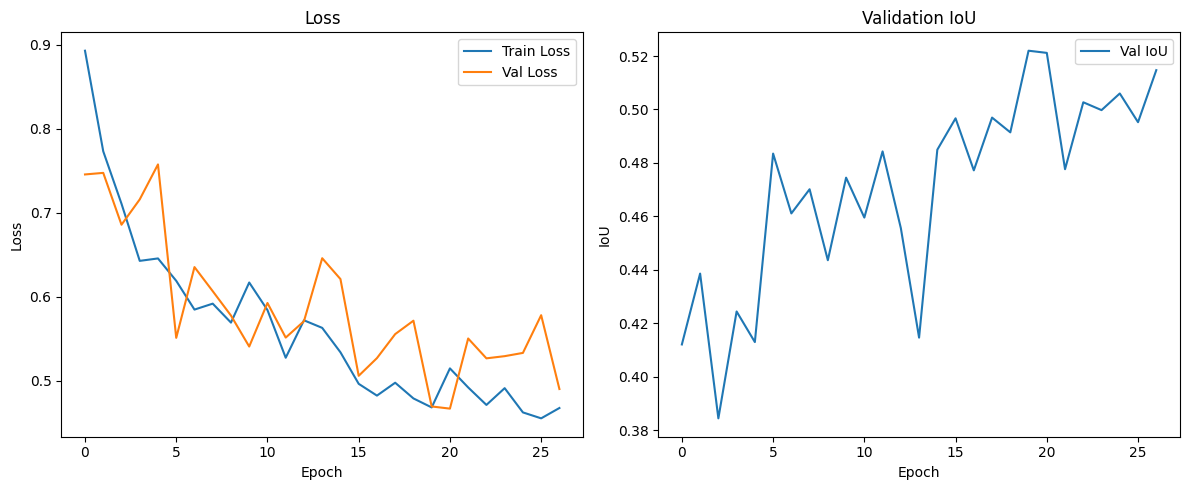

In [17]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(val_ious, label="Val IoU")
plt.title("Validation IoU")
plt.xlabel("Epoch")
plt.ylabel("IoU")
plt.legend()

plt.tight_layout()
plt.show()

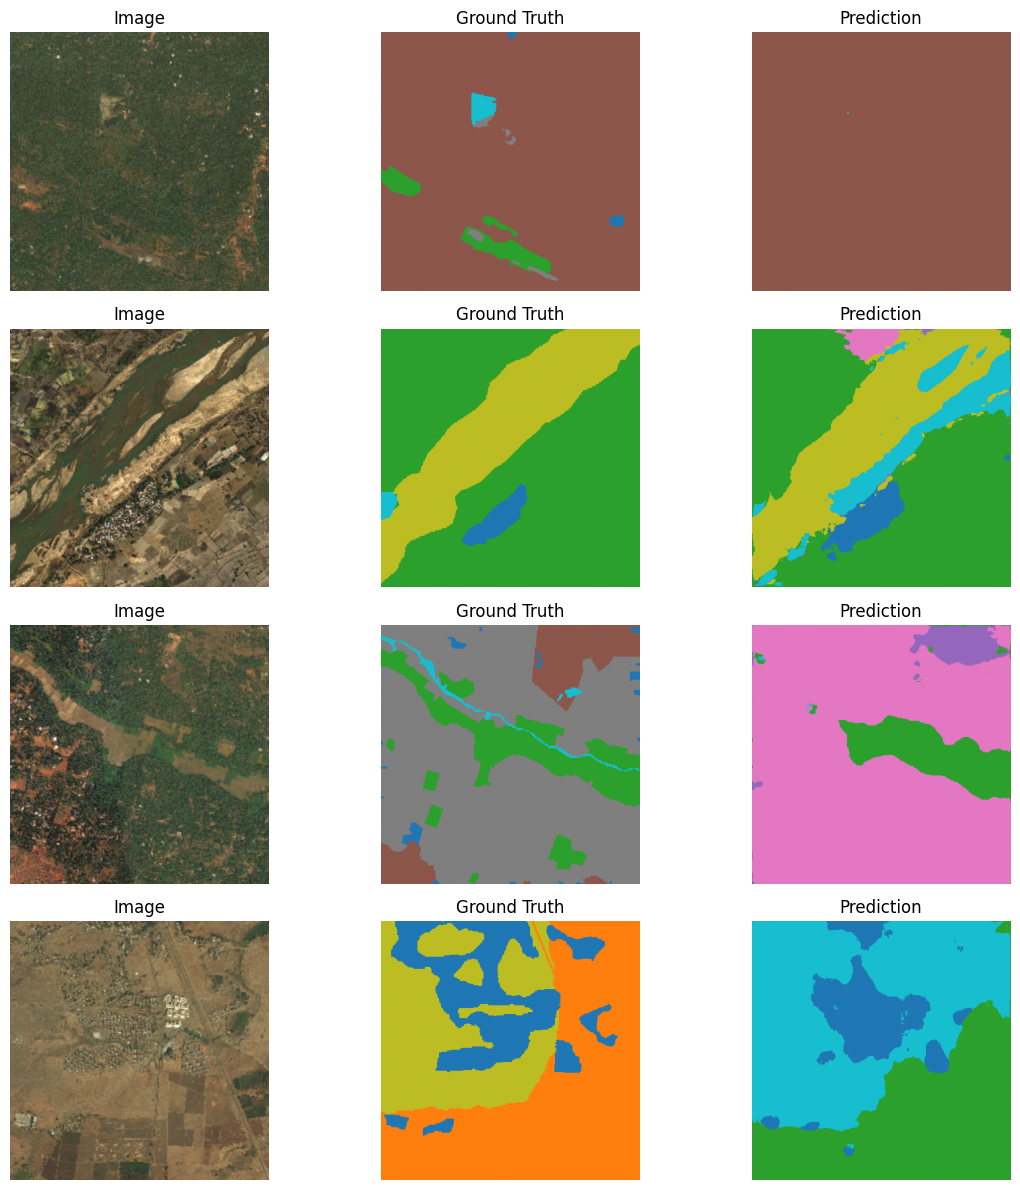

In [18]:
model.eval()

images, masks = next(iter(val_loader))
images = images.to(device)
masks = masks.to(device)
icount = 4
with torch.no_grad():
    outputs = model(images)
    preds = torch.argmax(outputs, dim=1)

images = images.cpu().permute(0, 2, 3, 1).numpy()
masks = masks.cpu().numpy()
preds = preds.cpu().numpy()

plt.figure(figsize=(12, 12))

for i in range(icount):
    plt.subplot(icount, 3, 3*i + 1)
    plt.imshow(denormalize_image(images[i]))
    plt.title("Image")
    plt.axis("off")

    plt.subplot(icount, 3, 3*i + 2)
    plt.imshow(masks[i], cmap="tab10")
    plt.title("Ground Truth")
    plt.axis("off")

    plt.subplot(icount, 3, 3*i + 3)
    plt.imshow(preds[i], cmap="tab10")
    plt.title("Prediction")
    plt.axis("off")

plt.tight_layout()
plt.show()

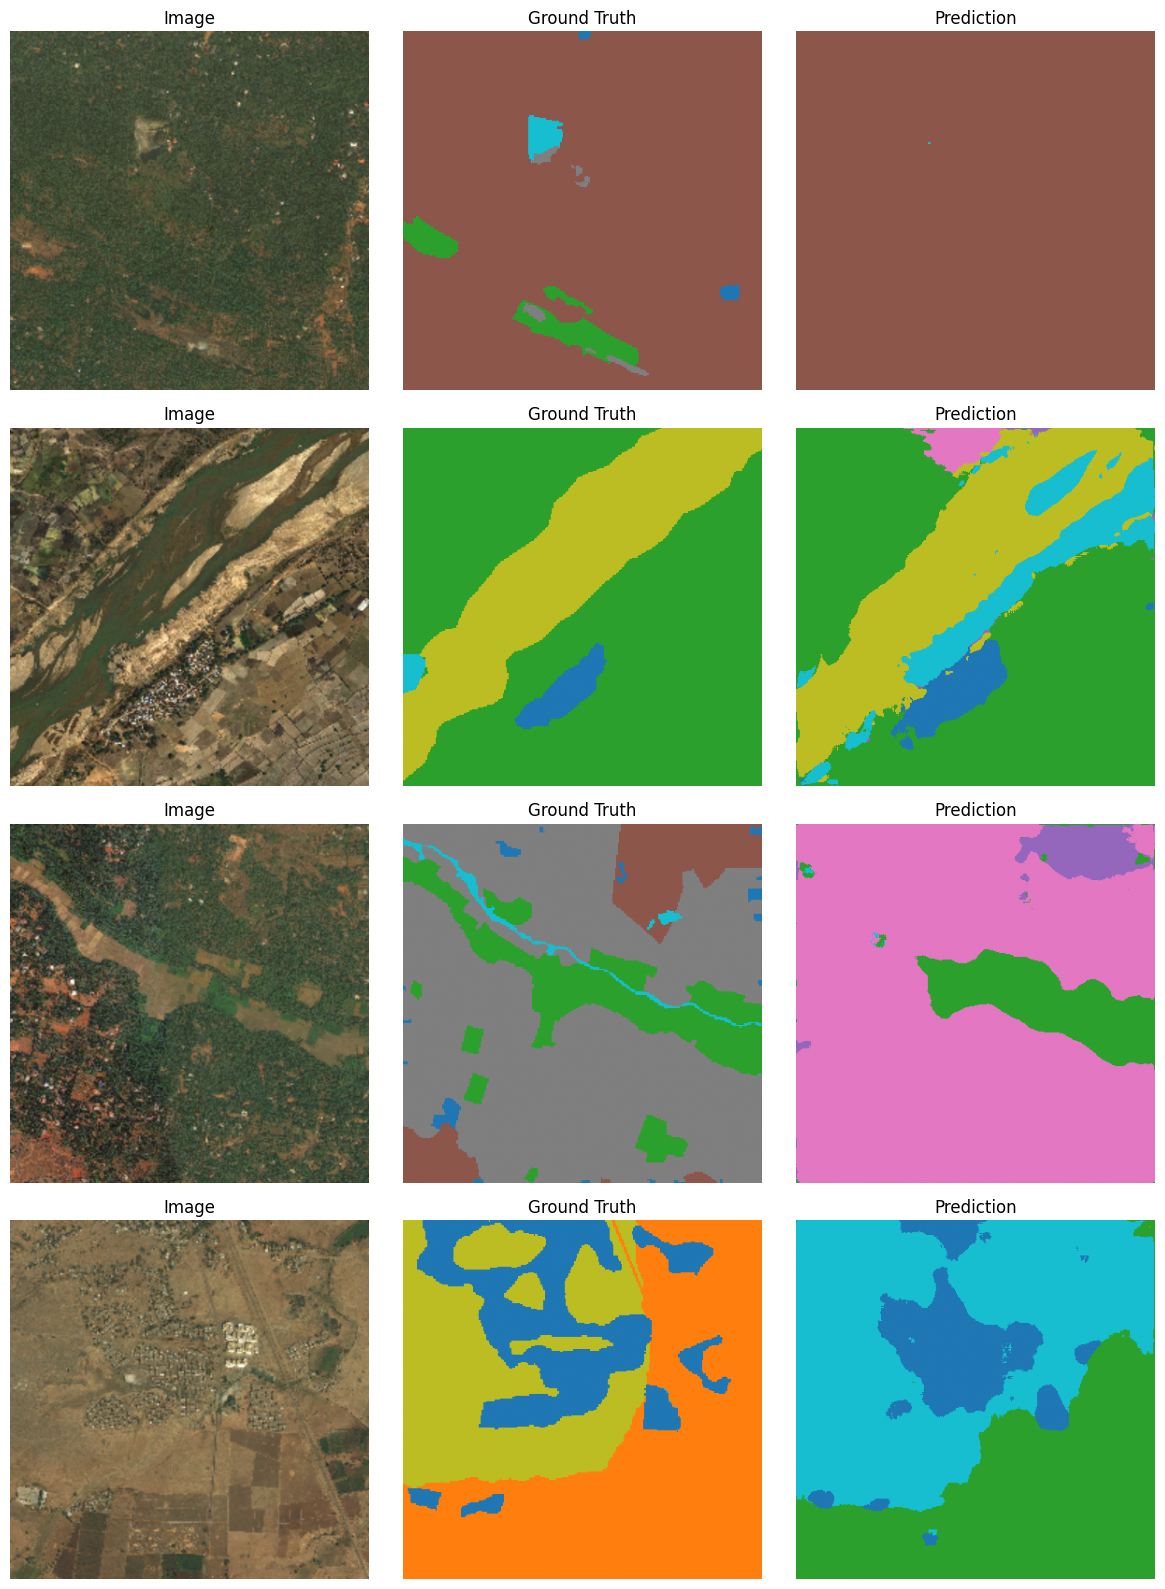

In [19]:
fig_dir = Path("../outputs/figures")
fig_dir.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(12, 16))

for i in range(icount):
    plt.subplot(icount, 3, 3*i + 1)
    plt.imshow(denormalize_image(images[i]))
    plt.title("Image")
    plt.axis("off")

    plt.subplot(icount, 3, 3*i + 2)
    plt.imshow(masks[i], cmap="tab10")
    plt.title("Ground Truth")
    plt.axis("off")

    plt.subplot(icount, 3, 3*i + 3)
    plt.imshow(preds[i], cmap="tab10")
    plt.title("Prediction")
    plt.axis("off")

plt.tight_layout()
plt.savefig(fig_dir / "prediction_examples_baseline.png", dpi=200, bbox_inches="tight")
plt.show()